# Customer Segmentation & Churn Pattern Analytics in European Banking
### Complete Production-Ready Descriptive Analytics and Machine Learning Pipeline

## Topic 1: Environment Ingestion & Dependency Configuration
This module initializes your required library ecosystem, tracking metrics, and custom formatting conditions.

In [2]:
pip install streamlit pandas numpy matplotlib seaborn scikit-learn joblib plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Rai\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import joblib

# Set styling preferences for consistent visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Environment setup completed successfully.")

Environment setup completed successfully.


## Topic 2: Data Loading & Architectural Validation
This step ingests the source file (`European_Bank.csv`) and performs initial target diagnostics to verify baseline field balance.

In [4]:
# Load the raw banking dataset
df = pd.read_csv("European_Bank.csv")

# Print dataset size metrics
print(f"Dataset structural dimensions: Rows: {df.shape[0]} | Columns: {df.shape[1]}\n")

# Display structural architecture and missing data profiles
print("=== Dataset Information ===")
print(df.info())

# Baseline display of top customer rows
print("\n=== Dataset Sample Overview ===")
print(df.head())

# Target distribution analysis for data verification
print("\n=== Target Variable ('Exited') Baseline Distribution ===")
target_counts = df['Exited'].value_counts()
target_pct = df['Exited'].value_counts(normalize=True) * 100
for idx in target_counts.index:
    print(f"Class {idx}: {target_counts[idx]} instances ({target_pct[idx]:.2f}%)")

Dataset structural dimensions: Rows: 10000 | Columns: 14

=== Dataset Information ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB
None

=== Dataset Sampl

## Topic 3: Automated Constraints & Variable Mapping Validation
Handles unique profile evaluations to confirm category properties and enforce data constraint validation profiles.

In [5]:
print("=== Unique Value Mapping Diagnoses ===")
print("Unique Product Count Values:", df['NumOfProducts'].unique())
print("Unique Credit Card Ownership Values:", df['HasCrCard'].unique())
print("Unique Active Status Values:", df['IsActiveMember'].unique())
print("Unique Churn Category Values:", df['Exited'].unique())

# Profile category counts for validation
print("\nProduct Mix Volumes:\n", df['NumOfProducts'].value_counts())
print("\nActive Engagement Volumes:\n", df['IsActiveMember'].value_counts())

=== Unique Value Mapping Diagnoses ===
Unique Product Count Values: [1 3 2 4]
Unique Credit Card Ownership Values: [1 0]
Unique Active Status Values: [1 0]
Unique Churn Category Values: [1 0]

Product Mix Volumes:
 NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

Active Engagement Volumes:
 IsActiveMember
1    5151
0    4849
Name: count, dtype: int64


## Topic 4: Structural Data Cleaning & Type Casting
This section purges non-analytical data tags (`Surname`) and updates raw textual parameters into formal pandas categories.

In [6]:
# Drop high-cardinality administrative string profiles to preserve memory
if 'Surname' in df.columns:
    df.drop('Surname', axis=1, inplace=True)
    print("Non-predictive analytical column 'Surname' purged successfully.")

# Cast categorical descriptors for efficient memory usage and structural typing
df['Geography'] = df['Geography'].astype('category')
df['Gender'] = df['Gender'].astype('category')

print(f"Updated Feature Schema Typings:\n{df.dtypes[['Geography', 'Gender']]}")

Non-predictive analytical column 'Surname' purged successfully.
Updated Feature Schema Typings:
Geography    category
Gender       category
dtype: object


## Topic 5: Derived Business Segmentation Engineering
Following your explicit requirement design rules, this engine groups continuous variables into strategic demographic and financial bands.

In [7]:
# 1. Age Segmentation
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[18, 30, 45, 60, 100],
    labels=['<30', '30-45', '46-60', '60+'],
    include_lowest=True
)

# 2. Credit Score Bands
df['CreditScoreBand'] = pd.cut(
    df['CreditScore'],
    bins=[300, 580, 700, 900],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

# 3. Tenure Groups
df['TenureGroup'] = pd.cut(
    df['Tenure'],
    bins=[-1, 3, 7, 10],
    labels=['New', 'Mid-Term', 'Long-Term'],
    include_lowest=True
)

# 4. Balance Segments
df['BalanceSegment'] = pd.cut(
    df['Balance'],
    bins=[-1, 0, 100000, 300000],
    labels=['Zero-Balance', 'Low-Balance', 'High-Balance'],
    include_lowest=True
)

print("Derived business segment attributes engineered successfully.")
print(df[['AgeGroup', 'CreditScoreBand', 'TenureGroup', 'BalanceSegment']].head())

Derived business segment attributes engineered successfully.
  AgeGroup CreditScoreBand TenureGroup BalanceSegment
0    30-45          Medium         New   Zero-Balance
1    30-45          Medium         New    Low-Balance
2    30-45             Low   Long-Term   High-Balance
3    30-45          Medium         New   Zero-Balance
4    30-45            High         New   High-Balance


## Topic 6: Exploratory Data Profiling & Comparative Churn Rates
This generates structural segment breakdowns and computes corresponding risk indicators across your customer groups.

In [8]:
print("=== Structural Segment Weight Contributions ===")
print("Geographic Mix (%):\n", df['Geography'].value_counts(normalize=True) * 100)
print("\nAge Group Distribution (%):\n", df['AgeGroup'].value_counts(normalize=True) * 100)

print("\n=== Segment-Specific Churn Ratios ===")
print("Overall Churn Benchmark Rate:", df['Exited'].mean() * 100)
print("\nGeographic Churn (%):\n", df.groupby('Geography', observed=True)['Exited'].mean() * 100)
print("\nAge Group Churn (%):\n", df.groupby('AgeGroup', observed=True)['Exited'].mean() * 100)
print("\nCredit Band Churn (%):\n", df.groupby('CreditScoreBand', observed=True)['Exited'].mean() * 100)
print("\nTenure Band Churn (%):\n", df.groupby('TenureGroup', observed=True)['Exited'].mean() * 100)
print("\nBalance Segment Churn (%):\n", df.groupby('BalanceSegment', observed=True)['Exited'].mean() * 100)

=== Structural Segment Weight Contributions ===
Geographic Mix (%):
 Geography
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64

Age Group Distribution (%):
 AgeGroup
30-45    59.21
<30      19.68
46-60    16.47
60+       4.64
Name: proportion, dtype: float64

=== Segment-Specific Churn Ratios ===
Overall Churn Benchmark Rate: 20.369999999999997

Geographic Churn (%):
 Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64

Age Group Churn (%):
 AgeGroup
<30       7.520325
30-45    15.740584
46-60    51.123254
60+      24.784483
Name: Exited, dtype: float64

Credit Band Churn (%):
 CreditScoreBand
Low       22.147931
Medium    19.772879
High      19.865212
Name: Exited, dtype: float64

Tenure Band Churn (%):
 TenureGroup
New          21.141227
Mid-Term     19.644645
Long-Term    20.448179
Name: Exited, dtype: float64

Balance Segment Churn (%):
 BalanceSegment
Zero-Balance    13.823611
Low-Balance     20.

## Topic 7: Multi-Dimensional Cross-Tabulation Analytics
This module analyzes the interactions between geographic constraints, age groups, and financial metrics to map patterns of customer exits.

In [9]:
print("=== Cross-Tabulation: Geography & Age-Group Risk Mapping ===")
geo_age_churn = pd.crosstab(
    df['AgeGroup'],
    df['Geography'],
    values=df['Exited'],
    aggfunc='mean'
) * 100
print(geo_age_churn)

print("\n=== Financial Profile Comparisons: Retained vs Churned ===")
financial_profile = df.groupby('Exited')[['CreditScore', 'Balance', 'EstimatedSalary']].mean()
print(financial_profile)

=== Cross-Tabulation: Geography & Age-Group Risk Mapping ===
Geography     France    Germany      Spain
AgeGroup                                  
<30         4.913295  12.362031   8.595388
30-45      12.349800  26.092991  12.533693
46-60      45.794393  67.330677  40.656566
60+        19.913420  38.938053  20.833333

=== Financial Profile Comparisons: Retained vs Churned ===
        CreditScore       Balance  EstimatedSalary
Exited                                            
0        651.853196  72745.296779     99738.391772
1        645.351497  91108.539337    101465.677531


## Topic 8: High-Value Customer Risk Quantification
This extracts high-balance customer rows (balance > 100,000) to isolate premium retention trends.

High-Value Account Volumes: 4799 profiles isolated.
High-Value Cohort Churn Exposure: 25.23%


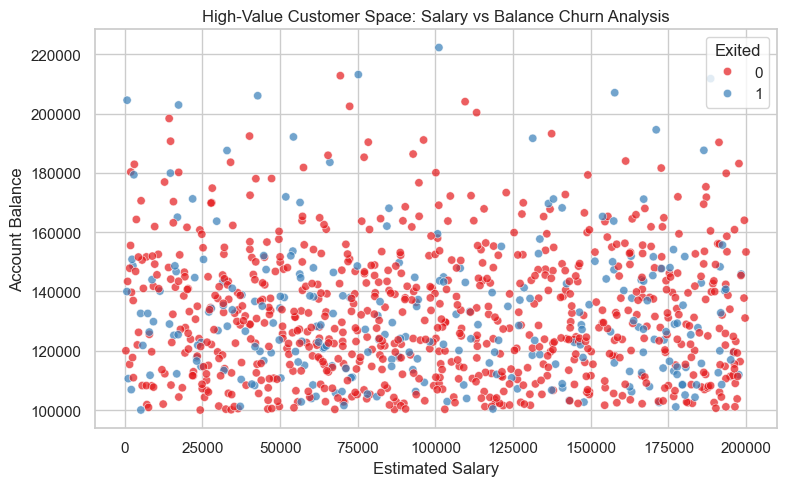

In [10]:
# Separate premium account parameters
high_value_customers = df[df['Balance'] > 100000].copy()

print(f"High-Value Account Volumes: {high_value_customers.shape[0]} profiles isolated.")
print(f"High-Value Cohort Churn Exposure: {high_value_customers['Exited'].mean() * 100:.2f}%")

# Generate exploratory correlation mapping across financial predictors
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=high_value_customers.sample(min(1000, len(high_value_customers)), random_state=42),
    x='EstimatedSalary',
    y='Balance',
    hue='Exited',
    alpha=0.7,
    palette='Set1'
)
plt.title('High-Value Customer Space: Salary vs Balance Churn Analysis')
plt.xlabel('Estimated Salary')
plt.ylabel('Account Balance')
plt.legend(title='Exited')
plt.tight_layout()
plt.show()

## Topic 9: Machine Learning Preprocessing (Feature Matrix Formulation)
To prevent feature leakage and handle textual categoricals, this module drops administrative tags and converts categories into numeric vectors.

In [11]:
# Drop identifiers and derived duplicates to ensure clean model parameters
ml_drop_cols = ['CustomerId', 'Year', 'Exited', 'AgeGroup', 'CreditScoreBand', 'TenureGroup', 'BalanceSegment']
X = df.drop(columns=[col for col in ml_drop_cols if col in df.columns])
y = df['Exited']

# One-hot encode string representations (Geography, Gender)
X = pd.get_dummies(X, columns=['Geography', 'Gender'], drop_first=True)

# Generate a stratified split to handle class distribution balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardize continuous variables
scaler = StandardScaler()
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Machine Learning Preprocessing Pipeline Complete:")
print(f"Final Features Array Shape: {X_train.shape} (Features Vectorized: {list(X.columns)})")

Machine Learning Preprocessing Pipeline Complete:
Final Features Array Shape: (8000, 11) (Features Vectorized: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male'])


## Topic 10: Model Execution & Balanced Evaluation Engine
This deploys a Random Forest Classifier with balanced training penalties to counteract the data imbalance.


=== CONFUSION MATRIX ===
[[1471  122]
 [ 176  231]]

=== PRODUCTION PERFORMANCE REPORT ===
              precision    recall  f1-score   support

           0       0.89      0.92      0.91      1593
           1       0.65      0.57      0.61       407

    accuracy                           0.85      2000
   macro avg       0.77      0.75      0.76      2000
weighted avg       0.84      0.85      0.85      2000

Area Under the ROC Curve (ROC-AUC): 0.8590


<Figure size 600x500 with 0 Axes>

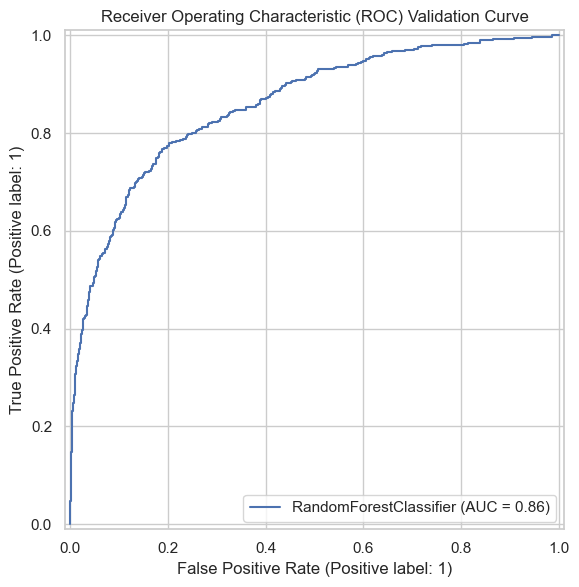

In [12]:
# Initialize and fit the ensemble classifier
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Calculate class predictions and probabilities
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("\n=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== PRODUCTION PERFORMANCE REPORT ===")
print(classification_report(y_test, y_pred))
print(f"Area Under the ROC Curve (ROC-AUC): {roc_auc_score(y_test, y_proba):.4f}")

# Render ROC Performance Curve
plt.figure(figsize=(6, 5))
RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.title('Receiver Operating Characteristic (ROC) Validation Curve')
plt.tight_layout()
plt.show()

## Topic 11: Feature Contribution Extraction
This extracts the exact driving metrics causing customers to drop out, providing quantitative input for your business summary.

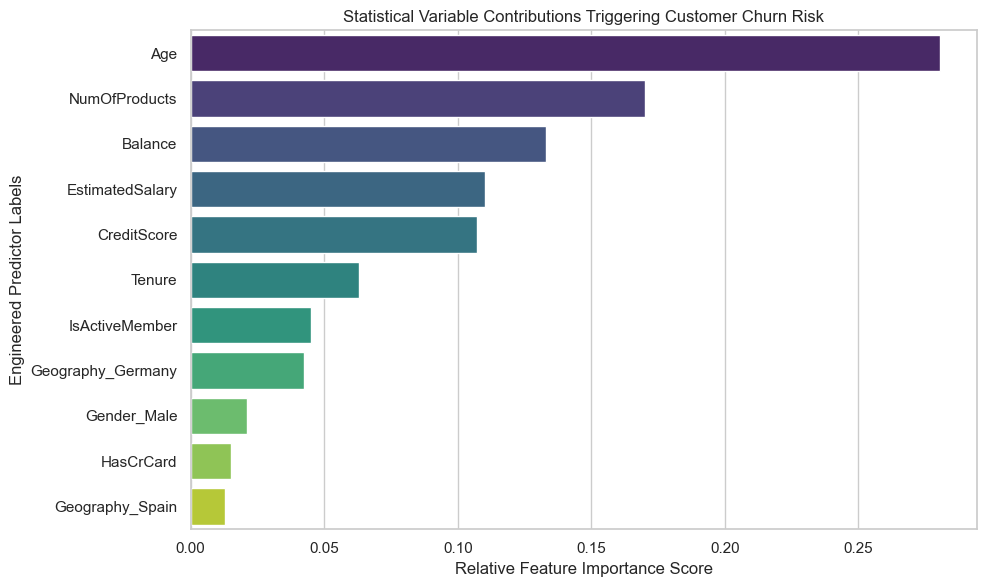

Top 3 Core Drivers Identified:
Age              0.280392
NumOfProducts    0.170045
Balance          0.133117
dtype: float64


In [13]:
# Compute relative feature contributions
importances = rf_model.feature_importances_
feature_names = X.columns
rf_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Render Feature Importance plot
plt.figure(figsize=(10, 6))
# Change this line in Topic 11:
sns.barplot(
    x=rf_importances.values, 
    y=rf_importances.index, 
    hue=rf_importances.index,   
    palette='viridis', 
    legend=False                
)
plt.title('Statistical Variable Contributions Triggering Customer Churn Risk', fontsize=12)
plt.xlabel('Relative Feature Importance Score')
plt.ylabel('Engineered Predictor Labels')
plt.tight_layout()
plt.show()

print("Top 3 Core Drivers Identified:")
print(rf_importances.head(3))

## Topic 12: Production Pipeline Serialization
This step saves the completed model artifacts and standardization mappings to your local disk, making them ready to load into your Streamlit web application modules.

In [14]:
# Export the trained model and feature scaler
joblib.dump(rf_model, 'european_bank_churn_model.pkl')
joblib.dump(scaler, 'fitted_standard_scaler.pkl')

# Save final column signatures for dynamic frontend input matching
joblib.dump(list(X.columns), 'model_feature_columns.pkl')

print("All production model components exported successfully.")
print("Files Generated: 'european_bank_churn_model.pkl', 'fitted_standard_scaler.pkl', 'model_feature_columns.pkl'")

All production model components exported successfully.
Files Generated: 'european_bank_churn_model.pkl', 'fitted_standard_scaler.pkl', 'model_feature_columns.pkl'
